# DoubleML Tutorial 01: DML Theory, Orthogonalization, And Cross-Fitting

This notebook explains the theory that makes DoubleML useful. The package is easiest to trust when the mechanics are not mysterious: nuisance functions are estimated with machine learning, the target causal parameter is estimated through an orthogonal score, and cross-fitting keeps nuisance prediction honest.

The running example is a partially linear regression design:

$$
Y = \theta_0 D + g_0(X) + \varepsilon,
$$

where `Y` is the outcome, `D` is a treatment or exposure, `X` is a vector of controls, `g_0(X)` is an unknown outcome nuisance function, and `theta_0` is the causal parameter we want. Treatment assignment is also modeled as

$$
D = m_0(X) + V.
$$

DoubleML estimates `g_0(X)` and `m_0(X)` flexibly, but it does not treat those prediction models as the final goal. The final goal is the low-dimensional causal parameter `theta_0` and its uncertainty.

Estimated runtime: about 1 minute on a typical laptop.

## Learning Goals

By the end of this notebook, you should be able to:

- explain why naive treatment-outcome regression can be biased under confounding;
- explain why plugging machine-learning predictions into causal estimators can create regularization bias;
- derive the partially linear orthogonal score at an intuitive level;
- describe why Neyman orthogonality reduces sensitivity to nuisance-model mistakes;
- implement manual cross-fitting for a PLR score;
- distinguish DML1-style fold averaging from DML2-style pooled score solving;
- connect the manual calculations to `DoubleMLPLR`.

## Tutorial Flow

The notebook proceeds in seven steps:

1. set up the environment and output folders;
2. simulate a high-dimensional confounded PLR dataset with known truth;
3. compare naive and adjusted baselines;
4. introduce orthogonal residual scores;
5. demonstrate nuisance perturbation robustness;
6. implement sample splitting and cross-fitting manually;
7. compare manual DML1, manual DML2, and `DoubleMLPLR`.

## Setup

This cell imports the packages used in the notebook, prepares output directories, and suppresses known non-substantive notebook warnings. We set `MPLCONFIGDIR` before importing plotting libraries so Matplotlib cache files stay inside the project outputs folder.

In [1]:
from pathlib import Path
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import doubleml as dml
from sklearn.base import clone
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

NOTEBOOK_PREFIX = "01"
RANDOM_SEED = 42
TRUE_THETA = 1.0
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

print(f"Project root: {PROJECT_ROOT}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"DoubleML version: {getattr(dml, '__version__', 'not exposed')}")

Project root: /home/apex/Documents/ranking_sys
Output folder: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs
DoubleML version: 0.11.2


The setup confirms the environment and creates a stable place for saved artifacts. This notebook uses `LassoCV` for the main nuisance learners because the synthetic design below is sparse and high-dimensional.

## Version Table

Theory notebooks still benefit from version logging. The exact learner behavior, defaults, and output formatting can change across package versions.

In [2]:
from importlib import metadata

packages = ["doubleml", "numpy", "pandas", "scikit-learn", "matplotlib", "seaborn"]
version_table = []
for package in packages:
    try:
        version = metadata.version(package)
    except metadata.PackageNotFoundError:
        version = None
    version_table.append({"package": package, "version": version})
version_table = pd.DataFrame(version_table)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)

,package,version
0,doubleml,0.11.2
1,numpy,2.4.4
2,pandas,3.0.2
3,scikit-learn,1.6.1
4,matplotlib,3.10.9
5,seaborn,0.13.2


This small table gives the notebook a reproducibility anchor. If a future run changes slightly, the package versions are one of the first things to check.

## Theory Map

Before coding, we summarize the main theory concepts. Each row in the table will appear again in executable form later in the notebook.

In [3]:
theory_map = pd.DataFrame(
    [
        {
            "concept": "confounding",
            "plain_language_role": "Controls affect both treatment and outcome, so naive treatment-outcome association is not causal.",
            "where_it_appears_below": "naive baseline estimate",
        },
        {
            "concept": "nuisance function",
            "plain_language_role": "A helper prediction function such as E[Y | X] or E[D | X].",
            "where_it_appears_below": "Lasso nuisance models",
        },
        {
            "concept": "regularization bias",
            "plain_language_role": "Bias caused when regularized nuisance prediction errors leak into the causal estimate.",
            "where_it_appears_below": "in-sample and memorizing learner demos",
        },
        {
            "concept": "orthogonal score",
            "plain_language_role": "A score designed so small nuisance mistakes have reduced first-order impact on theta.",
            "where_it_appears_below": "residualized PLR score",
        },
        {
            "concept": "cross-fitting",
            "plain_language_role": "Train nuisance functions on one fold and score held-out observations on another fold.",
            "where_it_appears_below": "manual K-fold DML implementation",
        },
        {
            "concept": "DML1 versus DML2",
            "plain_language_role": "DML1 averages fold-specific estimates; DML2 solves one pooled score after cross-fitting.",
            "where_it_appears_below": "manual fold table and pooled estimate",
        },
    ]
)
theory_map.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_theory_map.csv", index=False)
display(theory_map)

,concept,plain_language_role,where_it_appears_below
0,confounding,"Controls affect both treatment and outcome, so...",naive baseline estimate
1,nuisance function,A helper prediction function such as E[Y | X] ...,Lasso nuisance models
2,regularization bias,Bias caused when regularized nuisance predicti...,in-sample and memorizing learner demos
3,orthogonal score,A score designed so small nuisance mistakes ha...,residualized PLR score
4,cross-fitting,Train nuisance functions on one fold and score...,manual K-fold DML implementation
5,DML1 versus DML2,DML1 averages fold-specific estimates; DML2 so...,manual fold table and pooled estimate


The common thread is separation. DoubleML separates causal target estimation from nuisance prediction, and cross-fitting separates nuisance training rows from score-evaluation rows.

## Simulating A Confounded PLR Dataset

We use a synthetic dataset because it lets us know the true treatment effect. The controls `X` affect both treatment `D` and outcome `Y`, so a naive regression of `Y` on `D` will not recover the true effect.

The design is sparse and high-dimensional: there are many controls, but only the first few matter. That gives us a natural setting for regularized nuisance learners.

In [4]:
def simulate_sparse_plr(n_samples=500, n_controls=80, theta=TRUE_THETA, seed=RANDOM_SEED):
    """Create a sparse high-dimensional PLR dataset with known nuisance functions."""
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n_samples, n_controls))

    beta_m = np.zeros(n_controls)
    beta_g = np.zeros(n_controls)
    beta_m[:8] = [0.80, 0.70, 0.50, 0.40, 0.30, 0.25, 0.20, 0.15]
    beta_g[:8] = [1.00, 0.80, 0.60, 0.50, 0.40, 0.30, 0.20, 0.20]

    m0 = x @ beta_m
    g0 = x @ beta_g
    d = m0 + rng.normal(scale=1.0, size=n_samples)
    y = theta * d + g0 + rng.normal(scale=1.0, size=n_samples)
    l0 = theta * m0 + g0

    x_cols = [f"x{i + 1}" for i in range(n_controls)]
    observed_df = pd.DataFrame(x, columns=x_cols)
    observed_df.insert(0, "d", d)
    observed_df.insert(0, "y", y)

    oracle_df = pd.DataFrame({"m0_x": m0, "g0_x": g0, "l0_x": l0})
    return observed_df, oracle_df, x_cols

plr_df, oracle_df, x_cols = simulate_sparse_plr()
plr_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_sparse_plr_observed_data.csv", index=False)
oracle_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_sparse_plr_oracle_nuisance.csv", index=False)

display(plr_df.head())
print(f"Observed shape: {plr_df.shape}")
print(f"True theta: {TRUE_THETA:.2f}")

,y,d,x1,x2,x3,x4,x5,x6,x7,x8,...,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80
0,-2.981203,-1.565256,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,...,-1.275686,-1.133287,-0.919452,0.497161,0.142426,0.690485,-0.427253,0.158540,0.625590,-0.309347
1,-2.385550,-2.019338,0.456775,-0.661926,-0.363054,-0.381738,-1.195840,0.486972,-0.469402,0.012494,...,-0.158635,-1.035654,-1.674683,-0.486308,-0.053783,1.767930,0.130275,0.982740,-0.499296,-1.184944
2,-0.904904,0.058417,-0.965117,-0.725226,2.128470,-0.821387,0.838489,-0.902927,0.931573,0.384951,...,-1.463442,-0.590707,0.315605,1.205854,-0.729084,-0.654146,-2.147289,-0.162666,-1.062414,-0.529439
3,-5.046823,-1.706713,-0.876861,-0.094263,-1.757728,-1.467045,2.129247,-1.287423,-1.096786,1.836914,...,1.177412,0.439087,1.743935,0.438993,0.827988,-0.296571,0.066546,-0.697424,0.989584,-1.178304
4,1.938564,-0.441727,0.782350,-0.190651,1.171247,0.750869,1.820646,0.730775,-1.572040,-0.066953,...,-2.310103,0.054354,-0.471776,0.459386,0.701954,0.138241,0.760133,0.229211,0.530065,-0.704673


Observed shape: (500, 82)
True theta: 1.00


The observed data has the columns an analyst would see: outcome, treatment, and controls. The oracle nuisance columns are saved separately only for teaching; real datasets do not include true nuisance functions.

The next cell documents the variable roles. This matters because DoubleML uses column roles to define the score. A role mistake is not a small syntax issue; it changes the estimand.

In [5]:
variable_role_table = pd.DataFrame(
    [
        {"column_group": "y", "role": "outcome", "count": 1, "description": "Observed outcome."},
        {"column_group": "d", "role": "treatment", "count": 1, "description": "Continuous treatment or exposure."},
        {"column_group": "x1 through x80", "role": "controls", "count": len(x_cols), "description": "Pre-treatment controls used for nuisance adjustment."},
        {"column_group": "m0_x, g0_x, l0_x", "role": "oracle teaching columns", "count": 3, "description": "True nuisance values saved separately for theory checks only."},
    ]
)
variable_role_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_role_table.csv", index=False)
display(variable_role_table)

,column_group,role,count,description
0,y,outcome,1,Observed outcome.
1,d,treatment,1,Continuous treatment or exposure.
2,x1 through x80,controls,80,Pre-treatment controls used for nuisance adjus...
3,"m0_x, g0_x, l0_x",oracle teaching columns,3,True nuisance values saved separately for theo...


Only `y`, `d`, and the `x` columns will be passed to DoubleML. The oracle columns are useful for the theory demonstrations but would be unavailable in an applied analysis.

## Why Naive Regression Fails

The simplest mistake is to regress outcome on treatment while ignoring controls. Because the controls affect both treatment and outcome, the treatment coefficient absorbs part of the control effect.

We compare three estimates:

- naive regression of `y` on `d` only;
- full linear regression of `y` on `d` and all controls;
- oracle residual score using the true nuisance functions, available only because this is synthetic data.

In [6]:
def residual_score_theta(y, d, l_hat, m_hat):
    """Solve the PLR partialling-out score using supplied nuisance predictions."""
    y_resid = y - l_hat
    d_resid = d - m_hat
    denominator = np.mean(d_resid * d_resid)
    if denominator < 1e-12:
        return np.nan
    return np.mean(d_resid * y_resid) / denominator

naive_model = LinearRegression().fit(plr_df[["d"]], plr_df["y"])
linear_adjusted_model = LinearRegression().fit(plr_df[["d"] + x_cols], plr_df["y"])
oracle_theta = residual_score_theta(
    y=plr_df["y"].to_numpy(),
    d=plr_df["d"].to_numpy(),
    l_hat=oracle_df["l0_x"].to_numpy(),
    m_hat=oracle_df["m0_x"].to_numpy(),
)

baseline_estimates = pd.DataFrame(
    [
        {"method": "naive_y_on_d", "estimate": float(naive_model.coef_[0])},
        {"method": "linear_adjusted_y_on_d_plus_x", "estimate": float(linear_adjusted_model.coef_[0])},
        {"method": "oracle_residual_score", "estimate": float(oracle_theta)},
    ]
)
baseline_estimates["true_theta"] = TRUE_THETA
baseline_estimates["error"] = baseline_estimates["estimate"] - TRUE_THETA
baseline_estimates.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_baseline_estimates.csv", index=False)
display(baseline_estimates.round(4))

,method,estimate,true_theta,error
0,naive_y_on_d,1.7526,1.0,0.7526
1,linear_adjusted_y_on_d_plus_x,0.9960,1.0,-0.0040
2,oracle_residual_score,0.9884,1.0,-0.0116


The naive estimate is far from the true effect because it ignores confounding. The oracle residual score is close because it removes the true control-driven parts of outcome and treatment before estimating the treatment effect.

This plot shows the same comparison visually. The vertical dashed line is the true effect, available only in this controlled teaching example.

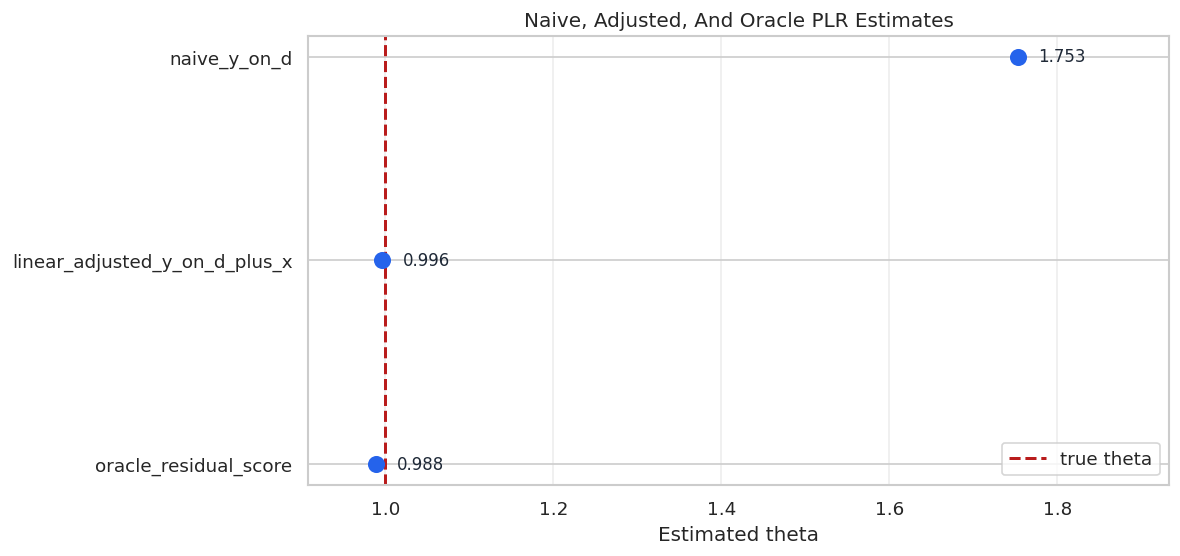

In [7]:
plot_df = baseline_estimates.sort_values("estimate").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.scatter(plot_df["estimate"], plot_df.index, s=85, color="#2563eb", zorder=3)
for row in plot_df.itertuples(index=True):
    ax.text(row.estimate + 0.025, row.Index, f"{row.estimate:.3f}", va="center", fontsize=10, color="#1f2937")
ax.axvline(TRUE_THETA, linestyle="--", linewidth=1.8, color="#b91c1c", label="true theta")
ax.set_yticks(plot_df.index)
ax.set_yticklabels(plot_df["method"])
ax.set_xlabel("Estimated theta")
ax.set_ylabel("")
ax.set_title("Naive, Adjusted, And Oracle PLR Estimates")
ax.set_xlim(min(plot_df["estimate"].min(), TRUE_THETA) - 0.08, max(plot_df["estimate"].max(), TRUE_THETA) + 0.18)
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_baseline_estimates.png", dpi=160, bbox_inches="tight")
plt.show()

The visual makes the confounding problem concrete. DoubleML is designed for the middle ground where the oracle functions are unknown, but flexible learners can estimate useful nuisance functions from controls.

## The Orthogonal PLR Score

The partialling-out score for PLR can be written as:

$$
\psi(W; \theta, \eta) = \{Y - l(X) - \theta(D - m(X))\}\{D - m(X)\},
$$

where `eta` collects the nuisance functions `l(X)` and `m(X)`. The target parameter solves:

$$
E[\psi(W; \theta_0, \eta_0)] = 0.
$$

For a sample with nuisance predictions, the closed-form residual estimate is:

$$
\hat\theta = \frac{\frac{1}{n}\sum_i (D_i - \hat m(X_i))(Y_i - \hat l(X_i))}{\frac{1}{n}\sum_i (D_i - \hat m(X_i))^2}.
$$

The key is not just residualization. The key is that the score is orthogonal: near the truth, small errors in `l` or `m` have reduced first-order impact on `theta`.

The next table turns the score into a set of operational pieces. These are the pieces that DoubleML automates internally.

In [8]:
score_pieces = pd.DataFrame(
    [
        {"piece": "Y - l_hat(X)", "role": "outcome residual", "why_it_matters": "Removes the part of the outcome explained by controls."},
        {"piece": "D - m_hat(X)", "role": "treatment residual", "why_it_matters": "Removes the part of treatment assignment explained by controls."},
        {"piece": "mean(treatment_residual * outcome_residual)", "role": "score numerator", "why_it_matters": "Measures remaining treatment-outcome movement after residualization."},
        {"piece": "mean(treatment_residual ** 2)", "role": "score denominator", "why_it_matters": "Measures remaining treatment variation after adjustment."},
        {"piece": "numerator / denominator", "role": "theta estimate", "why_it_matters": "Solves the sample analog of the orthogonal moment condition."},
    ]
)
score_pieces.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_score_pieces.csv", index=False)
display(score_pieces)

,piece,role,why_it_matters
0,Y - l_hat(X),outcome residual,Removes the part of the outcome explained by c...
1,D - m_hat(X),treatment residual,Removes the part of treatment assignment expla...
2,mean(treatment_residual * outcome_residual),score numerator,Measures remaining treatment-outcome movement ...
3,mean(treatment_residual ** 2),score denominator,Measures remaining treatment variation after a...
4,numerator / denominator,theta estimate,Solves the sample analog of the orthogonal mom...


This table is the simplest mental model for PLR DML: estimate nuisance functions, residualize outcome and treatment, then regress the residualized outcome on the residualized treatment.

## Orthogonality By Perturbation

Orthogonality can feel abstract, so we demonstrate it numerically. We start from the true nuisance functions and add controlled perturbations. Then we compare:

- the orthogonal residual score, which residualizes both outcome and treatment;
- a non-orthogonal residual score, which residualizes the outcome but does not residualize the treatment.

The orthogonal score should move more slowly as the nuisance perturbation grows.

In [9]:
x_matrix = plr_df[x_cols].to_numpy()
y_array = plr_df["y"].to_numpy()
d_array = plr_df["d"].to_numpy()
l0_array = oracle_df["l0_x"].to_numpy()
m0_array = oracle_df["m0_x"].to_numpy()

perturb_l = 0.60 * x_matrix[:, 0] - 0.30 * x_matrix[:, 3] + 0.20 * x_matrix[:, 9]
perturb_m = -0.40 * x_matrix[:, 1] + 0.25 * x_matrix[:, 2] - 0.15 * x_matrix[:, 10]


def non_orthogonal_theta(y, d, l_hat):
    """A deliberately less protected score: outcome residualized, treatment not residualized."""
    y_resid = y - l_hat
    return np.mean(d * y_resid) / np.mean(d * d)

perturbation_rows = []
base_non_orthogonal = non_orthogonal_theta(y_array, d_array, l0_array)
base_orthogonal = residual_score_theta(y_array, d_array, l0_array, m0_array)
for epsilon in [0.00, 0.01, 0.03, 0.05, 0.10, 0.20, 0.40]:
    l_perturbed = l0_array + epsilon * perturb_l
    m_perturbed = m0_array + epsilon * perturb_m
    orthogonal_estimate = residual_score_theta(y_array, d_array, l_perturbed, m_perturbed)
    non_orthogonal_estimate = non_orthogonal_theta(y_array, d_array, l_perturbed)
    perturbation_rows.append(
        {
            "epsilon": epsilon,
            "orthogonal_estimate": orthogonal_estimate,
            "orthogonal_change_from_epsilon_0": orthogonal_estimate - base_orthogonal,
            "non_orthogonal_estimate": non_orthogonal_estimate,
            "non_orthogonal_change_from_epsilon_0": non_orthogonal_estimate - base_non_orthogonal,
        }
    )

perturbation_table = pd.DataFrame(perturbation_rows)
perturbation_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_orthogonality_perturbation_table.csv", index=False)
display(perturbation_table.round(5))

,epsilon,orthogonal_estimate,orthogonal_change_from_epsilon_0,non_orthogonal_estimate,non_orthogonal_change_from_epsilon_0
0,0.00,0.98837,0.00000,0.41262,0.00000
1,0.01,0.98851,0.00014,0.41167,-0.00096
2,0.03,0.98865,0.00028,0.40976,-0.00287
3,0.05,0.98860,0.00023,0.40784,-0.00478
4,0.10,0.98766,-0.00072,0.40307,-0.00955
5,0.20,0.98231,-0.00606,0.39351,-0.01911
6,0.40,0.95858,-0.02980,0.37440,-0.03822


The orthogonal estimate changes more slowly near zero perturbation. The point is not that nuisance errors do not matter. They do. The point is that the score is designed to reduce first-order sensitivity around the correct nuisance functions.

The next plot shows the perturbation result. A flatter curve near zero is the numerical fingerprint of the orthogonal score.

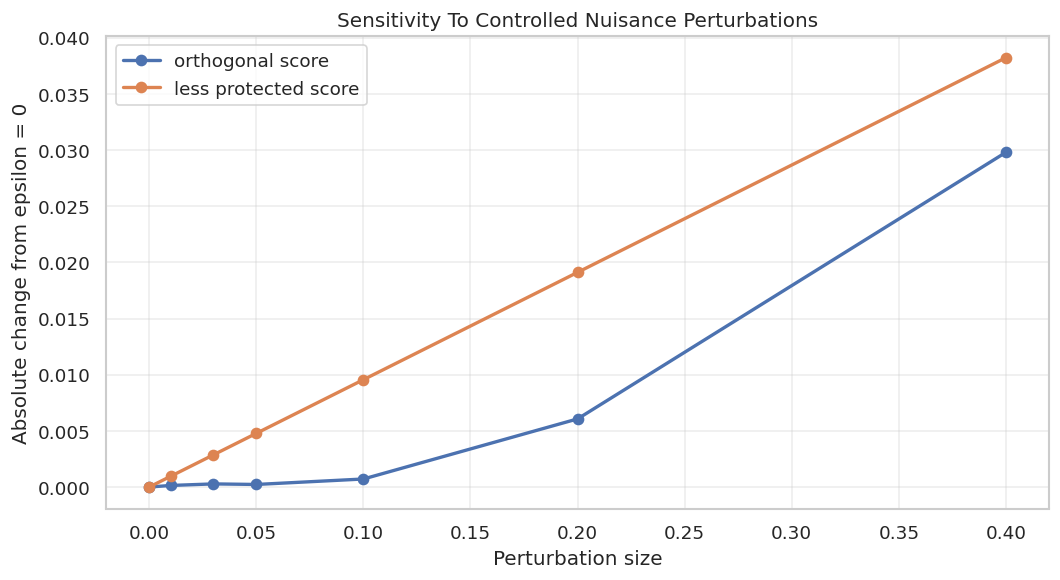

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    perturbation_table["epsilon"],
    perturbation_table["orthogonal_change_from_epsilon_0"].abs(),
    marker="o",
    linewidth=2,
    label="orthogonal score",
)
ax.plot(
    perturbation_table["epsilon"],
    perturbation_table["non_orthogonal_change_from_epsilon_0"].abs(),
    marker="o",
    linewidth=2,
    label="less protected score",
)
ax.set_title("Sensitivity To Controlled Nuisance Perturbations")
ax.set_xlabel("Perturbation size")
ax.set_ylabel("Absolute change from epsilon = 0")
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_orthogonality_perturbation.png", dpi=160, bbox_inches="tight")
plt.show()

The less protected score reacts more sharply to the same nuisance perturbation. This is why orthogonal scores are central to DoubleML.

## Regularization Bias And Memorizing Learners

Orthogonality helps with nuisance errors, but it does not license careless prediction. If a nuisance learner memorizes the training data and we evaluate it on the same rows, residuals can become artificially tiny. That can make the residual score unstable or meaningless.

This cell compares in-sample and cross-fitted residualization using a deliberately memorizing 1-nearest-neighbor learner.

In [11]:
memorizing_learner = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))

in_sample_l = clone(memorizing_learner).fit(plr_df[x_cols], plr_df["y"]).predict(plr_df[x_cols])
in_sample_m = clone(memorizing_learner).fit(plr_df[x_cols], plr_df["d"]).predict(plr_df[x_cols])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cf_l_mem = cross_val_predict(clone(memorizing_learner), plr_df[x_cols], plr_df["y"], cv=kf, n_jobs=-1)
cf_m_mem = cross_val_predict(clone(memorizing_learner), plr_df[x_cols], plr_df["d"], cv=kf, n_jobs=-1)

memorizing_table = pd.DataFrame(
    [
        {
            "approach": "in_sample_1nn_residualization",
            "theta_estimate": residual_score_theta(y_array, d_array, in_sample_l, in_sample_m),
            "treatment_residual_variance": float(np.mean((d_array - in_sample_m) ** 2)),
            "outcome_residual_variance": float(np.mean((y_array - in_sample_l) ** 2)),
        },
        {
            "approach": "cross_fitted_1nn_residualization",
            "theta_estimate": residual_score_theta(y_array, d_array, cf_l_mem, cf_m_mem),
            "treatment_residual_variance": float(np.mean((d_array - cf_m_mem) ** 2)),
            "outcome_residual_variance": float(np.mean((y_array - cf_l_mem) ** 2)),
        },
    ]
)
memorizing_table["true_theta"] = TRUE_THETA
memorizing_table["absolute_error"] = (memorizing_table["theta_estimate"] - TRUE_THETA).abs()
memorizing_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_memorizing_learner_table.csv", index=False)
display(memorizing_table.round(5))

,approach,theta_estimate,treatment_residual_variance,outcome_residual_variance,true_theta,absolute_error
0,in_sample_1nn_residualization,NaN,0.0000,0.00000,1.0,NaN
1,cross_fitted_1nn_residualization,1.69637,3.9741,14.97878,1.0,0.69637


The in-sample 1-nearest-neighbor learner nearly memorizes the outcome and treatment, leaving almost no residual treatment variation. Cross-fitting prevents the exact same row from being used for its own nuisance prediction, so the residual score becomes defined again, although the learner is still not a great choice here.

## Cross-Fitting With A Sensible Sparse Learner

Now we use `LassoCV`, which matches the sparse linear structure of the synthetic data. We compute nuisance predictions both in-sample and out-of-fold so the difference is explicit.

In [12]:
lasso_learner = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=RANDOM_SEED, n_jobs=-1, max_iter=20_000),
)

in_sample_l_lasso = clone(lasso_learner).fit(plr_df[x_cols], plr_df["y"]).predict(plr_df[x_cols])
in_sample_m_lasso = clone(lasso_learner).fit(plr_df[x_cols], plr_df["d"]).predict(plr_df[x_cols])
cf_l_lasso = cross_val_predict(clone(lasso_learner), plr_df[x_cols], plr_df["y"], cv=kf, n_jobs=-1)
cf_m_lasso = cross_val_predict(clone(lasso_learner), plr_df[x_cols], plr_df["d"], cv=kf, n_jobs=-1)

lasso_residual_table = pd.DataFrame(
    [
        {
            "approach": "in_sample_lasso_residualization",
            "theta_estimate": residual_score_theta(y_array, d_array, in_sample_l_lasso, in_sample_m_lasso),
            "ml_l_r2": r2_score(y_array, in_sample_l_lasso),
            "ml_m_r2": r2_score(d_array, in_sample_m_lasso),
        },
        {
            "approach": "cross_fitted_lasso_residualization",
            "theta_estimate": residual_score_theta(y_array, d_array, cf_l_lasso, cf_m_lasso),
            "ml_l_r2": r2_score(y_array, cf_l_lasso),
            "ml_m_r2": r2_score(d_array, cf_m_lasso),
        },
    ]
)
lasso_residual_table["true_theta"] = TRUE_THETA
lasso_residual_table["absolute_error"] = (lasso_residual_table["theta_estimate"] - TRUE_THETA).abs()
lasso_residual_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_lasso_residualization_table.csv", index=False)
display(lasso_residual_table.round(4))

,approach,theta_estimate,ml_l_r2,ml_m_r2,true_theta,absolute_error
0,in_sample_lasso_residualization,1.0084,0.8111,0.6249,1.0,0.0084
1,cross_fitted_lasso_residualization,0.9861,0.7888,0.5743,1.0,0.0139


The cross-fitted estimate is based on out-of-fold predictions. Its nuisance `R^2` values are lower than the in-sample values because held-out prediction is harder, but that honesty is exactly the point.

The next figure shows observed versus cross-fitted nuisance predictions. We are not trying to maximize predictive performance at all costs; we are checking that the nuisance learners capture meaningful control-driven signal.

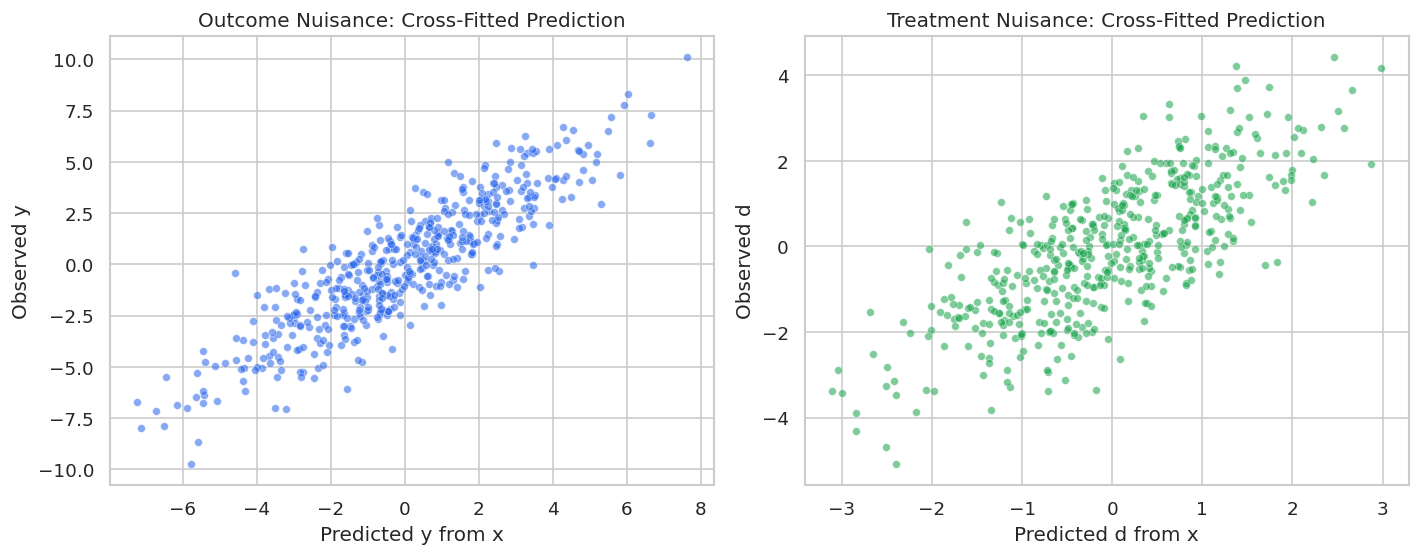

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(x=cf_l_lasso, y=y_array, s=22, alpha=0.55, color="#2563eb", ax=axes[0])
axes[0].set_title("Outcome Nuisance: Cross-Fitted Prediction")
axes[0].set_xlabel("Predicted y from x")
axes[0].set_ylabel("Observed y")

sns.scatterplot(x=cf_m_lasso, y=d_array, s=22, alpha=0.55, color="#16a34a", ax=axes[1])
axes[1].set_title("Treatment Nuisance: Cross-Fitted Prediction")
axes[1].set_xlabel("Predicted d from x")
axes[1].set_ylabel("Observed d")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cross_fitted_lasso_nuisance_predictions.png", dpi=160, bbox_inches="tight")
plt.show()

Both nuisance predictions contain signal. The treatment nuisance is particularly important because residual treatment variation is what identifies the partially linear effect after adjustment.

## Sample Splitting Mechanics

Cross-fitting uses repeated train and held-out roles. This cell records the fold sizes used in the manual calculations above. Every observation appears in exactly one held-out fold for this single split.

In [14]:
fold_rows = []
fold_assignment = np.empty(len(plr_df), dtype=int)
for fold_id, (train_idx, test_idx) in enumerate(kf.split(plr_df), start=1):
    fold_assignment[test_idx] = fold_id
    fold_rows.append(
        {
            "fold": fold_id,
            "train_rows": len(train_idx),
            "heldout_rows": len(test_idx),
            "heldout_share": len(test_idx) / len(plr_df),
        }
    )
fold_table = pd.DataFrame(fold_rows)
fold_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_manual_cross_fitting_fold_table.csv", index=False)
display(fold_table)

,fold,train_rows,heldout_rows,heldout_share
0,1,400,100,0.2
1,2,400,100,0.2
2,3,400,100,0.2
3,4,400,100,0.2
4,5,400,100,0.2


The fold table is simple but important. Reporting folds and random seeds helps make DML analyses reproducible.

This heatmap shows the held-out assignment for the first 100 rows. Each row is a fold; dark cells mark observations scored in that fold.

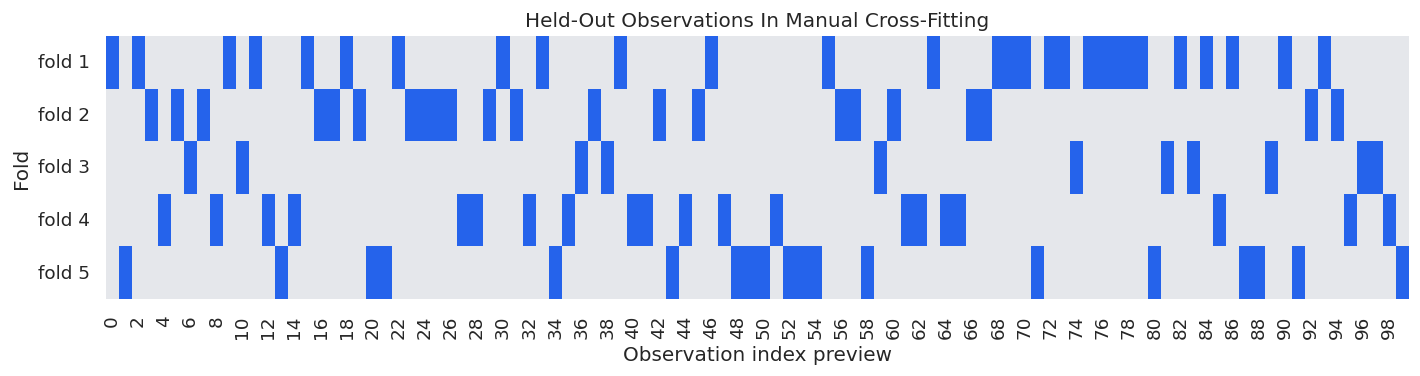

In [15]:
n_preview = 100
fold_matrix = np.zeros((5, n_preview), dtype=int)
for fold_id in range(1, 6):
    preview_indices = np.where((fold_assignment[:n_preview] == fold_id))[0]
    fold_matrix[fold_id - 1, preview_indices] = 1

fig, ax = plt.subplots(figsize=(12, 3.3))
sns.heatmap(
    fold_matrix,
    cmap=sns.color_palette(["#e5e7eb", "#2563eb"], as_cmap=True),
    cbar=False,
    linewidths=0.0,
    ax=ax,
)
ax.set_title("Held-Out Observations In Manual Cross-Fitting")
ax.set_xlabel("Observation index preview")
ax.set_ylabel("Fold")
ax.set_yticklabels([f"fold {i}" for i in range(1, 6)], rotation=0)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_manual_cross_fitting_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

The dark cells move across folds so each observation gets one held-out nuisance prediction. That held-out prediction is what enters the orthogonal score.

## DML1 Versus DML2

DML1 and DML2 use the same basic score but aggregate folds differently.

- **DML1:** solve the score separately in each fold, then average the fold-specific estimates.
- **DML2:** stack all cross-fitted residuals and solve one pooled score.

Many modern DoubleML workflows report a DML2-style pooled estimate. We compute both manually here because the distinction helps clarify what cross-fitting is doing.

In [16]:
fold_estimate_rows = []
for fold_id in range(1, 6):
    mask = fold_assignment == fold_id
    fold_theta = residual_score_theta(
        y=y_array[mask],
        d=d_array[mask],
        l_hat=cf_l_lasso[mask],
        m_hat=cf_m_lasso[mask],
    )
    fold_estimate_rows.append(
        {
            "fold": fold_id,
            "heldout_rows": int(mask.sum()),
            "fold_theta": fold_theta,
            "fold_error": fold_theta - TRUE_THETA,
        }
    )
fold_estimates = pd.DataFrame(fold_estimate_rows)
manual_dml1 = fold_estimates["fold_theta"].mean()
manual_dml2 = residual_score_theta(y_array, d_array, cf_l_lasso, cf_m_lasso)

fold_estimates.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_manual_dml1_fold_estimates.csv", index=False)
display(fold_estimates.round(4))
print(f"Manual DML1 fold-average theta: {manual_dml1:.4f}")
print(f"Manual DML2 pooled-score theta: {manual_dml2:.4f}")

,fold,heldout_rows,fold_theta,fold_error
0,1,100,1.0359,0.0359
1,2,100,0.8903,-0.1097
2,3,100,1.1253,0.1253
3,4,100,0.9148,-0.0852
4,5,100,0.9120,-0.0880


Manual DML1 fold-average theta: 0.9757
Manual DML2 pooled-score theta: 0.9861


The fold estimates vary because each held-out fold has its own residual distribution. DML1 averages those fold estimates; DML2 solves one pooled score across all held-out predictions.

The next plot shows fold-level variation and compares it with the pooled DML2 estimate and the true synthetic effect.

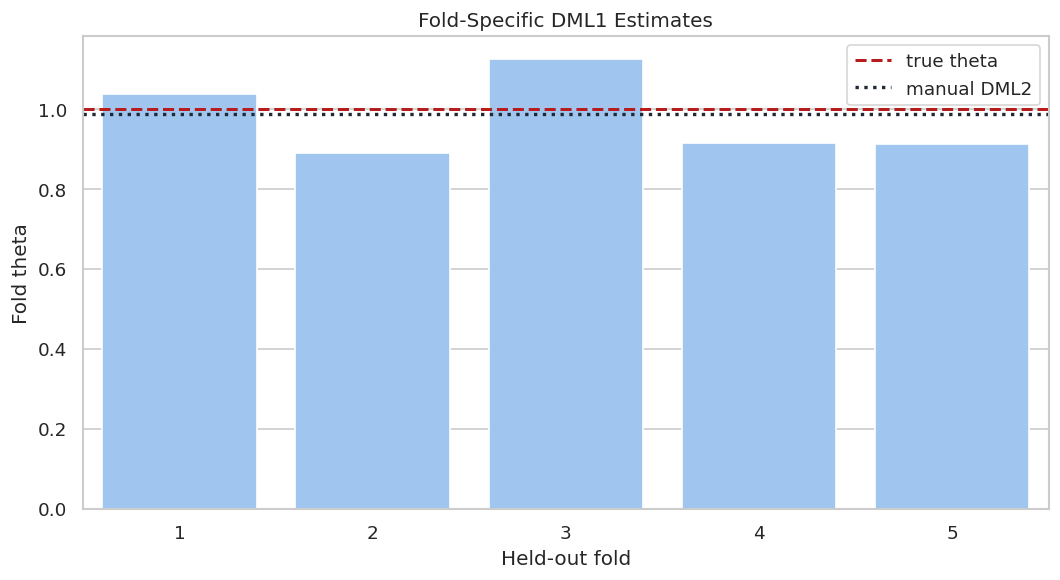

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=fold_estimates, x="fold", y="fold_theta", color="#93c5fd", ax=ax)
ax.axhline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.8, label="true theta")
ax.axhline(manual_dml2, color="#1f2937", linestyle=":", linewidth=2.0, label="manual DML2")
ax.set_title("Fold-Specific DML1 Estimates")
ax.set_xlabel("Held-out fold")
ax.set_ylabel("Fold theta")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_dml1_fold_estimates.png", dpi=160, bbox_inches="tight")
plt.show()

Fold variability is a useful reminder that sample splitting adds randomness. Later notebooks revisit repeated cross-fitting and split sensitivity more carefully.

## Connecting Manual DML To DoubleMLPLR

Now we fit `DoubleMLPLR` using the same observed dataset and a Lasso nuisance learner. The package handles sample splitting, nuisance fitting, score solving, standard errors, and confidence intervals.

In [18]:
dml_data = dml.DoubleMLData(plr_df, y_col="y", d_cols="d", x_cols=x_cols)
plr_model = dml.DoubleMLPLR(
    dml_data,
    ml_l=clone(lasso_learner),
    ml_m=clone(lasso_learner),
    n_folds=5,
    n_rep=1,
    score="partialling out",
)
plr_model.fit()
print(plr_model)

================== DoubleMLPLR Object ==================

------------------ Data Summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'x56', 'x57', 'x58', 'x59', 'x60', 'x61', 'x62', 'x63', 'x64', 'x65', 'x66', 'x67', 'x68', 'x69', 'x70', 'x71', 'x72', 'x73', 'x74', 'x75', 'x76', 'x77', 'x78', 'x79', 'x80']
Instrument variable(s): None
No. Observations: 500

------------------ Score & Algorithm ------------------
Score function: partialling out

------------------ Machine Learner   ------------------
Learner ml_l: Pipeline(steps=[('standardscaler', StandardScaler()),
        

The printed object summarizes the data roles, score, learners, and resampling plan. This is the package-level version of the manual workflow above.

This cell extracts the DoubleML summary and compares it with the manual DML calculations.

In [19]:
doubleml_summary = plr_model.summary.reset_index(names="treatment")
ci = plr_model.confint(level=0.95).reset_index(names="treatment")
ci = ci.rename(columns={"2.5 %": "ci_95_lower", "97.5 %": "ci_95_upper"})
doubleml_summary = doubleml_summary.merge(ci, on="treatment", how="left")
doubleml_summary["true_theta"] = TRUE_THETA
doubleml_summary["estimate_error"] = doubleml_summary["coef"] - TRUE_THETA

doubleml_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_doubleml_plr_summary.csv", index=False)
display(doubleml_summary.round(4))

,treatment,coef,std err,t,P>|t|,2.5 %,97.5 %,ci_95_lower,ci_95_upper,true_theta,estimate_error
0,d,0.9963,0.0431,23.1028,0.0,0.9118,1.0809,0.9118,1.0809,1.0,-0.0037


The DoubleML estimate is close to the manual cross-fitted residual estimate because both are solving the same PLR score idea. DoubleML additionally reports standard errors, p-values, and confidence intervals.

We collect all major estimates in one comparison table. This is a useful reporting habit because it separates confounding bias, adjustment behavior, and DML behavior.

In [20]:
estimate_comparison = pd.DataFrame(
    [
        {"method": "naive_y_on_d", "estimate": float(naive_model.coef_[0]), "uses_controls": False, "uses_cross_fitting": False},
        {"method": "linear_adjusted_y_on_d_plus_x", "estimate": float(linear_adjusted_model.coef_[0]), "uses_controls": True, "uses_cross_fitting": False},
        {"method": "oracle_residual_score", "estimate": float(oracle_theta), "uses_controls": True, "uses_cross_fitting": False},
        {"method": "manual_dml1_lasso", "estimate": float(manual_dml1), "uses_controls": True, "uses_cross_fitting": True},
        {"method": "manual_dml2_lasso", "estimate": float(manual_dml2), "uses_controls": True, "uses_cross_fitting": True},
        {"method": "doubleml_plr_lasso", "estimate": float(plr_model.coef[0]), "uses_controls": True, "uses_cross_fitting": True},
    ]
)
estimate_comparison["true_theta"] = TRUE_THETA
estimate_comparison["absolute_error"] = (estimate_comparison["estimate"] - TRUE_THETA).abs()
estimate_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_estimate_comparison.csv", index=False)
display(estimate_comparison.round(4))

,method,estimate,uses_controls,uses_cross_fitting,true_theta,absolute_error
0,naive_y_on_d,1.7526,False,False,1.0,0.7526
1,linear_adjusted_y_on_d_plus_x,0.9960,True,False,1.0,0.0040
2,oracle_residual_score,0.9884,True,False,1.0,0.0116
3,manual_dml1_lasso,0.9757,True,True,1.0,0.0243
4,manual_dml2_lasso,0.9861,True,True,1.0,0.0139
5,doubleml_plr_lasso,0.9963,True,True,1.0,0.0037


The table shows the main lesson of the notebook: the naive estimate is not a causal estimate in this design, while the residualized and cross-fitted estimates aim at the true treatment effect.

The comparison plot places all estimates against the true synthetic effect. This type of plot is helpful in simulations because it shows which procedures are targeting the right quantity.

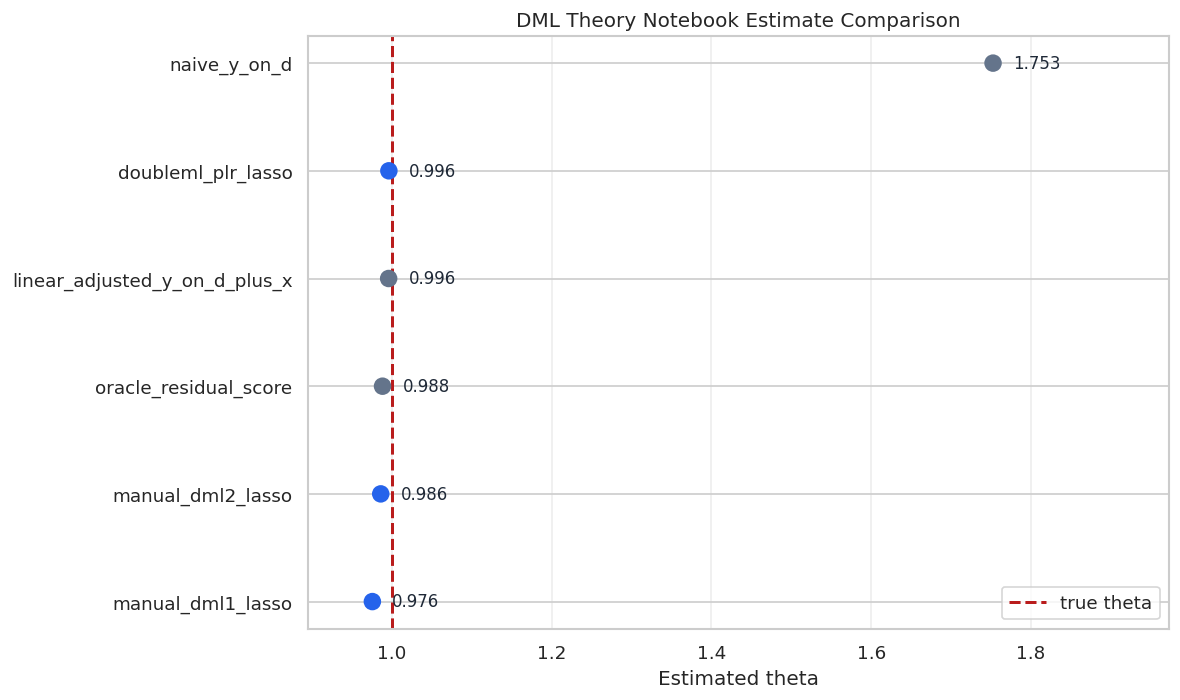

In [21]:
plot_df = estimate_comparison.sort_values("estimate").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(plot_df["uses_cross_fitting"], "#2563eb", "#64748b")
ax.scatter(plot_df["estimate"], plot_df.index, s=90, color=colors, zorder=3)
for row in plot_df.itertuples(index=True):
    ax.text(row.estimate + 0.025, row.Index, f"{row.estimate:.3f}", va="center", fontsize=10, color="#1f2937")
ax.axvline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.8, label="true theta")
ax.set_yticks(plot_df.index)
ax.set_yticklabels(plot_df["method"])
ax.set_xlabel("Estimated theta")
ax.set_ylabel("")
ax.set_title("DML Theory Notebook Estimate Comparison")
ax.set_xlim(min(plot_df["estimate"].min(), TRUE_THETA) - 0.08, max(plot_df["estimate"].max(), TRUE_THETA) + 0.22)
ax.grid(True, axis="x", alpha=0.35)
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The cross-fitted DML estimates cluster near the true value. The naive estimate remains far away because it does not address the confounding built into the simulation.

## Inspecting Score Elements

DoubleML stores score-related arrays after fitting. These are advanced internal outputs, but seeing their shapes helps connect the package object to the theory. For one treatment and one repeated split, the score arrays have an observation dimension plus treatment and repetition dimensions.

In [22]:
score_diagnostics = pd.DataFrame(
    [
        {"object": "psi", "shape": str(np.asarray(plr_model.psi).shape), "description": "Score values evaluated at the fitted theta."},
        {"object": "psi_deriv", "shape": str(np.asarray(plr_model.psi_deriv).shape), "description": "Score derivative values used for standard errors."},
    ]
)
score_diagnostics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_score_diagnostics.csv", index=False)
display(score_diagnostics)

,object,shape,description
0,psi,"(500, 1, 1)",Score values evaluated at the fitted theta.
1,psi_deriv,"(500, 1, 1)",Score derivative values used for standard errors.


Most users do not need to work directly with these arrays, but they are a useful bridge between the mathematical score and the fitted DoubleML object.

## Nuisance Losses And Prediction Quality

The final theory point is that nuisance quality matters, even with orthogonal scores. Orthogonality reduces first-order sensitivity, but very poor nuisance models can still hurt finite-sample performance.

DoubleML reports nuisance losses. We also compute simple out-of-fold prediction quality from the stored nuisance predictions.

In [23]:
nuisance_loss_table = pd.DataFrame(
    [
        {
            "learner_role": learner_role,
            "loss_value": float(np.asarray(loss_value).ravel()[0]),
            "loss_type": "mean squared error for regression nuisance learner",
        }
        for learner_role, loss_value in plr_model.nuisance_loss.items()
    ]
)
nuisance_loss_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_doubleml_nuisance_losses.csv", index=False)
display(nuisance_loss_table.round(4))

,learner_role,loss_value,loss_type
0,ml_l,1.4449,mean squared error for regression nuisance lea...
1,ml_m,1.0515,mean squared error for regression nuisance lea...


The loss table gives a quick check of nuisance fit. These losses should be read as diagnostics, not as the causal estimand.

This cell reads DoubleML's stored nuisance predictions and computes simple `RMSE` and `R2` diagnostics for each nuisance role.

In [24]:
doubleml_pred_l = np.asarray(plr_model.predictions["ml_l"]).squeeze()
doubleml_pred_m = np.asarray(plr_model.predictions["ml_m"]).squeeze()

prediction_quality = pd.DataFrame(
    [
        {
            "nuisance_role": "ml_l predicts y from x",
            "rmse": mean_squared_error(y_array, doubleml_pred_l) ** 0.5,
            "r2": r2_score(y_array, doubleml_pred_l),
        },
        {
            "nuisance_role": "ml_m predicts d from x",
            "rmse": mean_squared_error(d_array, doubleml_pred_m) ** 0.5,
            "r2": r2_score(d_array, doubleml_pred_m),
        },
    ]
)
prediction_quality.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_doubleml_nuisance_prediction_quality.csv", index=False)
display(prediction_quality.round(4))

,nuisance_role,rmse,r2
0,ml_l predicts y from x,1.4449,0.7859
1,ml_m predicts d from x,1.0515,0.5640


The nuisance learners capture meaningful signal from the controls. That is what we need: not perfect prediction, but useful residualization for the target causal score.

## Reporting Checklist For DML Theory

A theory notebook still needs a reporting checklist. These are the items that should appear whenever you use DoubleML in a real analysis.

In [25]:
reporting_checklist = pd.DataFrame(
    [
        {"check": "Target parameter named", "status_here": "theta in a PLR design", "why_it_matters": "The estimand must be clear before choosing learners."},
        {"check": "Identification assumptions stated", "status_here": "controls are sufficient by construction in synthetic data", "why_it_matters": "DoubleML does not create identification by itself."},
        {"check": "Nuisance roles documented", "status_here": "ml_l for outcome nuisance and ml_m for treatment nuisance", "why_it_matters": "Different DoubleML classes require different nuisance roles."},
        {"check": "Cross-fitting plan documented", "status_here": "5-fold split with fixed random seed", "why_it_matters": "Resampling choices can affect finite-sample estimates."},
        {"check": "Baselines compared", "status_here": "naive, linear adjusted, oracle, manual DML, DoubleML", "why_it_matters": "Baselines reveal what the DML workflow is correcting."},
        {"check": "Nuisance diagnostics reported", "status_here": "losses and out-of-fold prediction quality saved", "why_it_matters": "Poor nuisance fit can still matter."},
        {"check": "Uncertainty reported", "status_here": "DoubleML standard errors and confidence interval saved", "why_it_matters": "A causal estimate without uncertainty is incomplete."},
    ]
)
reporting_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_reporting_checklist.csv", index=False)
display(reporting_checklist)

,check,status_here,why_it_matters
0,Target parameter named,theta in a PLR design,The estimand must be clear before choosing lea...
1,Identification assumptions stated,controls are sufficient by construction in syn...,DoubleML does not create identification by its...
2,Nuisance roles documented,ml_l for outcome nuisance and ml_m for treatme...,Different DoubleML classes require different n...
3,Cross-fitting plan documented,5-fold split with fixed random seed,Resampling choices can affect finite-sample es...
4,Baselines compared,"naive, linear adjusted, oracle, manual DML, Do...",Baselines reveal what the DML workflow is corr...
5,Nuisance diagnostics reported,losses and out-of-fold prediction quality saved,Poor nuisance fit can still matter.
6,Uncertainty reported,DoubleML standard errors and confidence interv...,A causal estimate without uncertainty is incom...


The checklist separates theory, implementation, and reporting. That separation is the habit that makes DoubleML work credible.

## Artifact Manifest

The final cell records every file created by the notebook. This makes the run easier to audit and keeps later notebooks organized.

In [26]:
artifact_paths = sorted(
    list(DATASET_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(TABLE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(FIGURE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(REPORT_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
)
artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": path.parent.name,
            "path": str(path.relative_to(OUTPUT_DIR)),
            "size_kb": round(path.stat().st_size / 1024, 2),
        }
        for path in artifact_paths
    ]
)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,path,size_kb
0,datasets,datasets/01_sparse_plr_observed_data.csv,786.04
1,datasets,datasets/01_sparse_plr_oracle_nuisance.csv,28.44
2,figures,figures/01_baseline_estimates.png,51.20
3,figures,figures/01_cross_fitted_lasso_nuisance_predict...,167.06
4,figures,figures/01_dml1_fold_estimates.png,36.85
5,figures,figures/01_estimate_comparison.png,74.06
6,figures,figures/01_manual_cross_fitting_heatmap.png,45.81
7,figures,figures/01_orthogonality_perturbation.png,92.90
8,tables,tables/01_baseline_estimates.csv,0.22
9,tables,tables/01_doubleml_nuisance_losses.csv,0.18


## Closing Notes

The core theory has three moving parts:

- residualize outcome and treatment using nuisance functions;
- use an orthogonal score so small nuisance errors have reduced first-order impact;
- use cross-fitting so nuisance predictions are evaluated out of sample.

The next notebook moves from theory to data setup. It focuses on `DoubleMLData`, variable roles, and design-specific data containers.